# 0. Imports

In [90]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

## 0.1. Helper Functions

In [91]:
def plot_distribuicao_por_grupos(df_contratado, df_adimplente, df_inadimplente, col, titulo_legenda=None):
    """
    Plota a distribuição de uma variável categórica ao longo do tempo para três grupos.
    Linhas são interrompidas quando os valores são zero e todos os gráficos usam a mesma escala.
    """
    
    # Criar as tabelas para cada grupo
    tabela_contratado = pd.crosstab(df_contratado['ano_mes'], df_contratado[col], normalize='index')
    tabela_adimplente = pd.crosstab(df_adimplente['ano_mes'], df_adimplente[col], normalize='index')
    tabela_inadimplente = pd.crosstab(df_inadimplente['ano_mes'], df_inadimplente[col], normalize='index')
    
    # Substituir valores 0 por NaN para criar descontinuidades nas linhas
    tabela_contratado = tabela_contratado.replace(0, np.nan)
    tabela_adimplente = tabela_adimplente.replace(0, np.nan)
    tabela_inadimplente = tabela_inadimplente.replace(0, np.nan)
    
    # Encontrar o valor máximo entre todas as tabelas para definir a mesma escala
    max_valor = max(
        tabela_contratado.max().max() if not tabela_contratado.empty else 0,
        tabela_adimplente.max().max() if not tabela_adimplente.empty else 0,
        tabela_inadimplente.max().max() if not tabela_inadimplente.empty else 0
    )
    
    # Adicionar uma pequena margem no topo (10% a mais)
    ylim_max = min(max_valor * 1.1, 1.0)  # Não ultrapassar 100%
    
    # Criar figura com 3 subplots lado a lado
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Lista com as tabelas e títulos
    tabelas = [
        (tabela_contratado, 'Contratados Total'),
        (tabela_adimplente, 'Adimplentes'),
        (tabela_inadimplente, 'Inadimplentes')
    ]
    
    # Título geral da figura
    fig.suptitle(f'Distribuição de {col} ao longo do tempo', 
                 fontsize=16)
    
    # Plotar cada gráfico
    for ax, (tabela, titulo) in zip(axes, tabelas):
        tabela.plot(ax=ax, figsize=(18,5), legend=False)


        # Pintar fundo dos diferentes períodos         
        ax.axvspan('2022-03-01', '2023-03-01', color='lightgreen', alpha=0.3)         # Janela de Modelagem
        ax.axvspan('2023-03-01', '2024-03-01', color='lightblue', alpha=0.3)          # Janela de Observação
        ax.axvspan('2024-05-01', tabela.index.max(), color='lightpink', alpha=0.3)    # Em Produção
        
        ax.axvspan('2024-03-01', '2024-05-01', color='black', alpha=0.4)              # Limbo
        ax.axvspan('2023-03-01', '2023-03-01', color='black', alpha=0.4)              # Marcador
        ax.axvspan('2023-09-01', '2023-09-01', color='black', alpha=0.4)              # Efeito Modelo Teste
        ax.axvspan('2025-03-01', '2025-03-01', color='black', alpha=0.4)              # Marcador
        
        ax.axvspan('2024-10-01', '2025-01-01', color='orange', alpha=0.4)             # Efeito Modelo Produção
        ax.axvspan('2025-01-01', tabela.index.max(), color='lightgray', alpha=0.4)    # Não tem target 1
        
        ax.set_title(titulo)
        ax.set_xlabel('Ano-Mês')
        ax.set_ylabel('Proporção %')
        
        # Definir a mesma escala para todos os gráficos
        ax.set_ylim(0, ylim_max)
        
        # Formatar y-axis como porcentagem
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
        
        # Rotacionar labels do eixo x para melhor legibilidade
        ax.tick_params(axis='x', rotation=45)
    
    # Criar uma única legenda para todos os gráficos
    lines = axes[0].get_lines()
    labels = [line.get_label() for line in lines]
    
    # Definir título da legenda
    if titulo_legenda is None:
        titulo_legenda = f'Valores de {col}'
    
    # Posicionar a legenda fora dos gráficos
    fig.legend(lines, labels, 
               loc='center', 
               bbox_to_anchor=(0.5, -0.05),
               ncol=len(labels),
               title=titulo_legenda,
               columnspacing=1.5)
    
    # Ajustar espaçamento para não cortar a legenda
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.2)
    
    plt.show()
    
    return fig, axes

In [92]:
def plot_estatisticas_por_tipo(df, col_numerica, titulo=None):
    """
    Plota média, mediana e coeficiente de variação de uma variável numérica 
    ao longo do tempo para cada tipo.
    
    Parameters:
    -----------
    df : DataFrame
        DataFrame com as colunas 'ano_mes', 'tipo' e a coluna numérica
    col_numerica : str
        Nome da coluna numérica a ser analisada
    titulo : str, optional
        Título personalizado para o gráfico
    """
    
    # Calcular estatísticas por ano_mes e tipo
    df_stats = df.groupby(['ano_mes', 'tipo'])[col_numerica].agg([
        ('media', 'mean'),
        ('mediana', 'median'),
        ('std', 'std')
    ]).reset_index()
    
    # Calcular coeficiente de variação (CV = std/mean)
    df_stats['cv'] = df_stats['std'] / df_stats['media']
    
    # Ordenar tipos para consistência nas cores
    ordem_tipos = ['Adimplente', 'Inadimplente', 'Nao_Contratado']
    cores = {'Nao_Contratado': '#95A5A6', 
             'Adimplente': '#2ECC71', 
             'Inadimplente': '#E74C3C'}
    
    # Criar figura com 3 subplots lado a lado
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Lista com as estatísticas e títulos
    estatisticas = [
        ('media', 'Média'),
        ('mediana', 'Mediana'),
        ('cv', 'Coeficiente de Variação (σ/μ)')
    ]
    
    # Título geral da figura
    titulo_geral = titulo if titulo else f'Estatísticas de {col_numerica} ao longo do tempo'
    fig.suptitle(titulo_geral, fontsize=16)
    
    # Plotar cada gráfico
    for ax, (estatistica, titulo_graf) in zip(axes, estatisticas):
        
        # Plotar linhas para cada tipo
        for tipo in ordem_tipos:
            dados_tipo = df_stats[df_stats['tipo'] == tipo]
            if not dados_tipo.empty:
                ax.plot(dados_tipo['ano_mes'], dados_tipo[estatistica], 
                       'o-', label=tipo, color=cores.get(tipo, '#333333'), 
                       linewidth=2.5, markersize=6)
        
        # Pintar fundo dos períodos (mesmos em todos os gráficos)
        ax.axvspan('2022-03-01', '2023-03-01', color='lightgreen', alpha=0.3)  # Janela de Modelagem
        ax.axvspan('2023-03-01', '2024-03-01', color='lightblue', alpha=0.3)   # Janela de Observação
        ax.axvspan('2024-05-01', '2025-12-01', color='lightpink', alpha=0.3)   # Em Produção
        ax.axvspan('2024-03-01', '2024-05-01', color='black', alpha=0.4)       # Limbo
        ax.axvspan('2023-03-01', '2023-03-01', color='black', alpha=0.4)       # Marcador
        ax.axvspan('2023-09-01', '2023-09-01', color='black', alpha=0.4)       # Efeito Modelo Teste
        ax.axvspan('2025-03-01', '2025-03-01', color='black', alpha=0.4)       # Marcador
        ax.axvspan('2024-10-01', '2025-01-01', color='orange', alpha=0.4)      # Efeito Modelo Produção
        ax.axvspan('2025-01-01', '2025-12-01', color='lightgray', alpha=0.4)   # Não tem target 1
        
        # Configurações específicas para CV
        if estatistica == 'cv':
            ax.set_ylabel('Coeficiente de Variação', fontsize=12)
            # Adicionar linha de referência para CV=0.2 (alta variabilidade)
            ax.axhline(y=0.2, color='red', linestyle='--', alpha=0.5, linewidth=1, label='CV=0.2')
        else:
            ax.set_ylabel(f'{titulo_graf} de {col_numerica}', fontsize=12)
        
        ax.set_xlabel('Ano-Mês', fontsize=12)
        ax.set_title(titulo_graf, fontsize=13)
        ax.tick_params(axis='x', rotation=45)
        ax.legend(loc='best', fontsize=9)
        ax.grid(True, alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.85)  # Ajustar para o título geral
    plt.show()
    
    return fig, axes

## 0.2. Loading Data

In [93]:
# Load do arquivo
path_data  = "../data/"
df = pd.read_csv(path_data + '2_envio_case_base_Total_2026.csv', sep=';', encoding='latin-1')

# Formatação da coluna 'ano_mes' para datetime
df['ano_mes'] = pd.to_datetime(df['ano_mes'], format='%Y%m')

df.head()

,id,ano_mes,idade_veiculo,marca,vl_bem,idade,estado_civil,qt_restr,renda,Regiao,Profissao,entrada,prazo,pmt,target,FPD,score,contratado
0,534521536,2023-01-01,3_5,Chevrolet,"(25000, 70000]",43,solteiro,0,18422,SE,liberais,20,12,2775,0.0,0.0,8,1
1,894445785,2023-01-01,10,Chevrolet,"(25000, 70000]",39,solteiro,0,11175,N,empresarios,20,48,734,0.0,0.0,5,1
2,510004819,2023-01-01,1_2,Fiat,"(25000, 70000]",37,solteiro,>2,26031,NE,consignados,30,36,1510,1.0,0.0,7,1
3,230978528,2023-01-01,10,VW,"(25000, 70000]",61,casado,0,3009,SE,empresarios,20,36,1588,1.0,0.0,4,1
4,489909079,2023-01-01,3_5,Fiat,"(25000, 70000]",48,casado,2,10253,CO,assalariados,30,12,2712,0.0,0.0,8,1


# 1. EDA

## 1.0. Análise por feature

PERÍODO                | DESCRIÇÃO            | Observação         
--                     | --                   | --
['202203' - '202303')  | Janela de modelagem  | 
['202303' - '202403')  | Janela de observação | ['202303']: Marcador, <br>['202309']: Efeito Modelo Teste
['202403' - '202405')  | Limbo                | 
['202405']             | Implantado           | 
['202405' - 202512]    | Em produção          | ['202410', '202501'): Efeito Modelo Produção, <br>['202501', '202512'): Não tem taget = 1, <br>['202503']: Marcador

## 1.0.1. Variáveis Categóricas

FEATURE       | Mudou? | OBSERVAÇÃO
--            | --     | --
score         |        | **
FPD           |        | 
Profissao     | não    | 
Regiao        |        | 
idade_veiculo |        | 
vl_bem        |        | 
qt_restr      |        | 
marca         |        | 
estado_civil  |        | 
entrada       |        | 
prazo         |        | 

## 1.0.2. Variáveis Numéricas

FEATURE   | OBSERVAÇÃO
--        | --
idade     | 
pmt       | 
renda     | 


## 0.1. Filtro e seleção

In [94]:
# Separar os dados em contratados e não contratados
df_nao_contratado = df[(df['contratado'] == 0)].copy() # Não Contratado (Ponto Cego)
df_contratado     = df[(df['contratado'] == 1)].copy() # Contratado Total

# Separar os dados em contratados inadimplentes e adimplentes
df_adimplente   = df[(df['target'] == 0)].copy() # Adimplente
df_inadimplente = df[(df['target'] == 1)].copy() # Inadimplente     

In [95]:
# Definir condições
condicoes = [
    (df['contratado'] == 0),                        # Não Contratado (Ponto Cego)
    (df['contratado'] == 1) & (df['target'] == 0),  # Adimplente
    (df['contratado'] == 1) & (df['target'] == 1)   # Inadimplente
]

# Definir valores correspondentes
valores = [
    'Nao_Contratado',
    'Adimplente',
    'Inadimplente',
]

# Criar a coluna tipo
df['tipo'] = np.select(condicoes, valores, default='Desconhecido')

In [96]:
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
cat_cols = cat_cols + ['FPD', 'entrada', 'prazo', 'score']
cat_cols = sorted(cat_cols)

num_cols = sorted(['idade', 'pmt', 'renda'])

## 1.1. Análise Descritiva

In [97]:
total_base = len(df)
total_contratados = len(df_contratado)

# Imprimir o total de registros em cada grupo
print("---" ) 
print("QUANTIDADE DE REGISTROS POR TIPO")
print("  1. Não contratados  : ", f"{len(df_nao_contratado):,}", f"| {len(df_nao_contratado)/total_base:.2%} da base")
print("  2. Contratados      : ", f"{len(df_contratado):,}", f"| {len(df_contratado)/total_base:.2%} da base")
print("     - Adimplentes    : ", f"{len(df_adimplente):,}", f"| {len(df_adimplente)/total_contratados:.2%} dos contratados ")
print("     - Inadimplentes  : ", f"{len(df_inadimplente):,} ", f"| {len(df_inadimplente)/total_contratados:.2%} dos contratados")

# Imprimir o período de análise por grupo
print("\n" "---" ) 
print("PERÍODO DE ANÁLISE POR TIPO")
print(f"  1. Não contratados  :  {df_nao_contratado['ano_mes'].min()} a {df_nao_contratado['ano_mes'].max()}")
print(f"  2. Contratado       :  {df_contratado['ano_mes'].min()} a {df_contratado['ano_mes'].max()}")
print(f"     - Adimplente     :  {df_adimplente['ano_mes'].min()} a {df_adimplente['ano_mes'].max()}")
print(f"     - Inadimplente   :  {df_inadimplente['ano_mes'].min()} a {df_inadimplente['ano_mes'].max()}")

---
QUANTIDADE DE REGISTROS POR TIPO
  1. Não contratados  :  192,550 | 22.71% da base
  2. Contratados      :  655,451 | 77.29% da base
     - Adimplentes    :  587,596 | 89.65% dos contratados 
     - Inadimplentes  :  67,855  | 10.35% dos contratados

---
PERÍODO DE ANÁLISE POR TIPO
  1. Não contratados  :  2022-03-01 00:00:00 a 2025-12-01 00:00:00
  2. Contratado       :  2022-03-01 00:00:00 a 2025-12-01 00:00:00
     - Adimplente     :  2022-03-01 00:00:00 a 2025-12-01 00:00:00
     - Inadimplente   :  2022-03-01 00:00:00 a 2024-12-01 00:00:00


In [98]:
df_contratado.describe().T

,count,mean,min,25%,50%,75%,max,std
id,655451.0,550344829.796738,100000316.0,325319883.5,550605692.0,775445026.5,999999446.0,259875560.850485
ano_mes,655451,2023-12-06 12:45:31.459102,2022-03-01 00:00:00,2023-01-01 00:00:00,2023-12-01 00:00:00,2024-11-01 00:00:00,2025-12-01 00:00:00,NaN
idade,655451.0,40.315195,18.0,34.0,40.0,47.0,87.0,9.87442
renda,655451.0,13709.077272,3000.0,4397.0,12327.0,22792.0,27576.0,9016.625373
entrada,655451.0,24.292022,0.0,10.0,20.0,40.0,50.0,15.661309
prazo,655451.0,39.351372,12.0,36.0,36.0,48.0,60.0,10.990441
pmt,655451.0,1198.184763,216.0,752.0,1089.0,1486.0,9197.0,654.266414
target,655451.0,0.103524,0.0,0.0,0.0,0.0,1.0,0.304642
FPD,655451.0,0.03315,0.0,0.0,0.0,0.0,1.0,0.179027
score,655451.0,6.751287,1.0,6.0,7.0,8.0,10.0,1.65564


## 1.2. Análise Visual

### 1.2.1. Variáveis Categóricas

In [99]:
df[df['vl_bem'] == '25a70']

,id,ano_mes,idade_veiculo,marca,vl_bem,idade,estado_civil,qt_restr,renda,Regiao,Profissao,entrada,prazo,pmt,target,FPD,score,contratado,tipo
399824,362933522,2022-11-01,3_5,Outros,25a70,44,solteiro,0,3045,SE,prof_serv,20,24,2698,1.0,0.0,5,1,Inadimplente


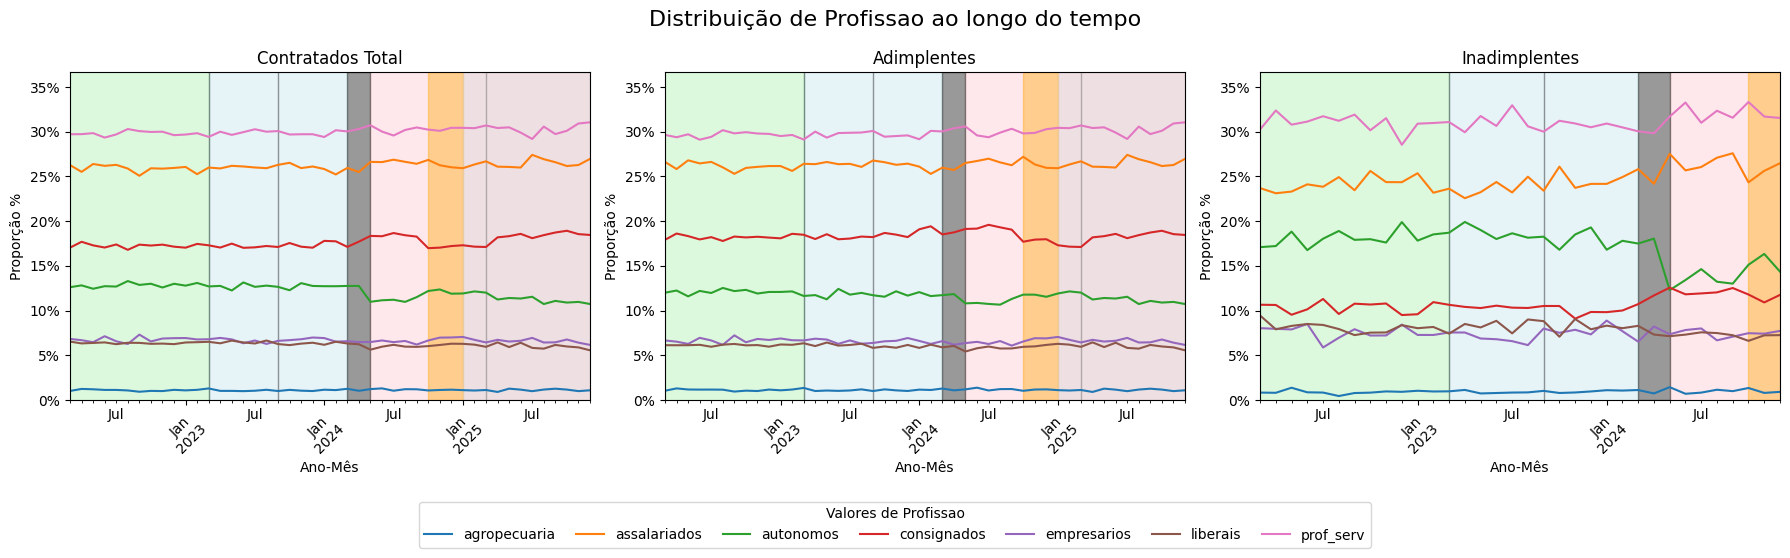

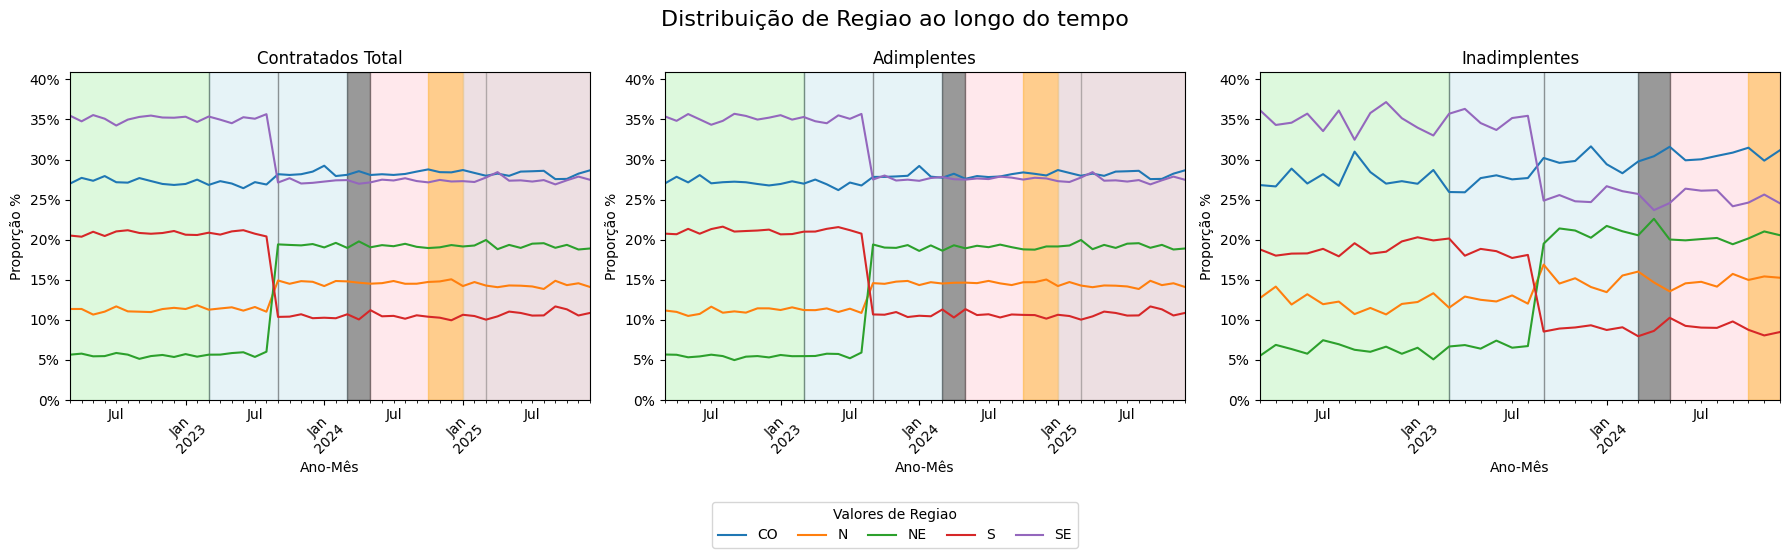

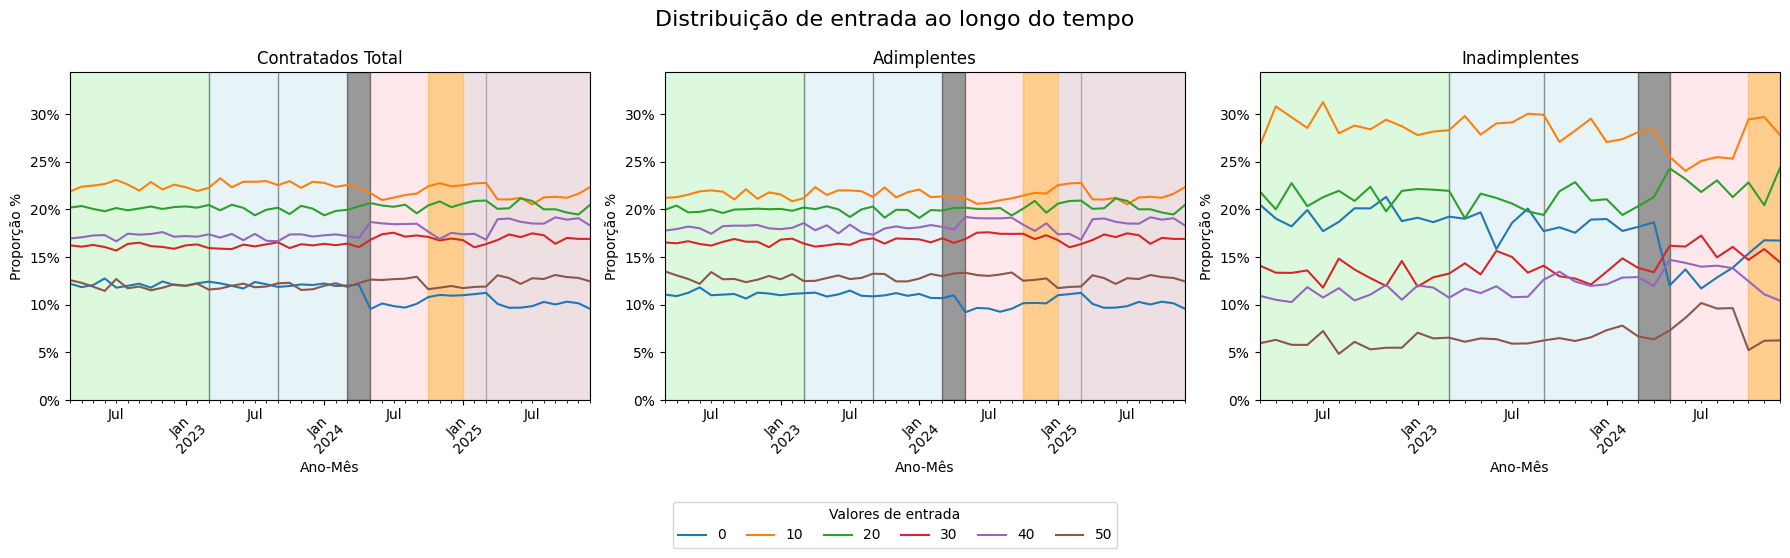

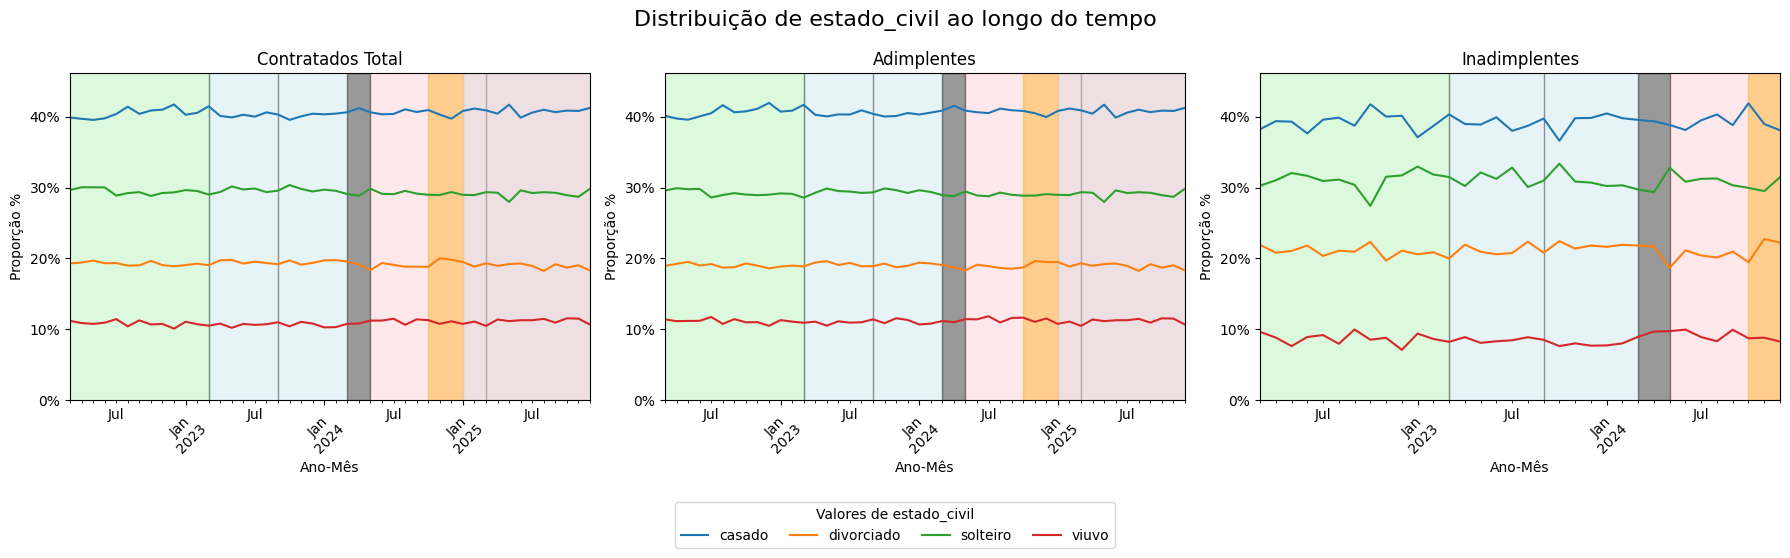

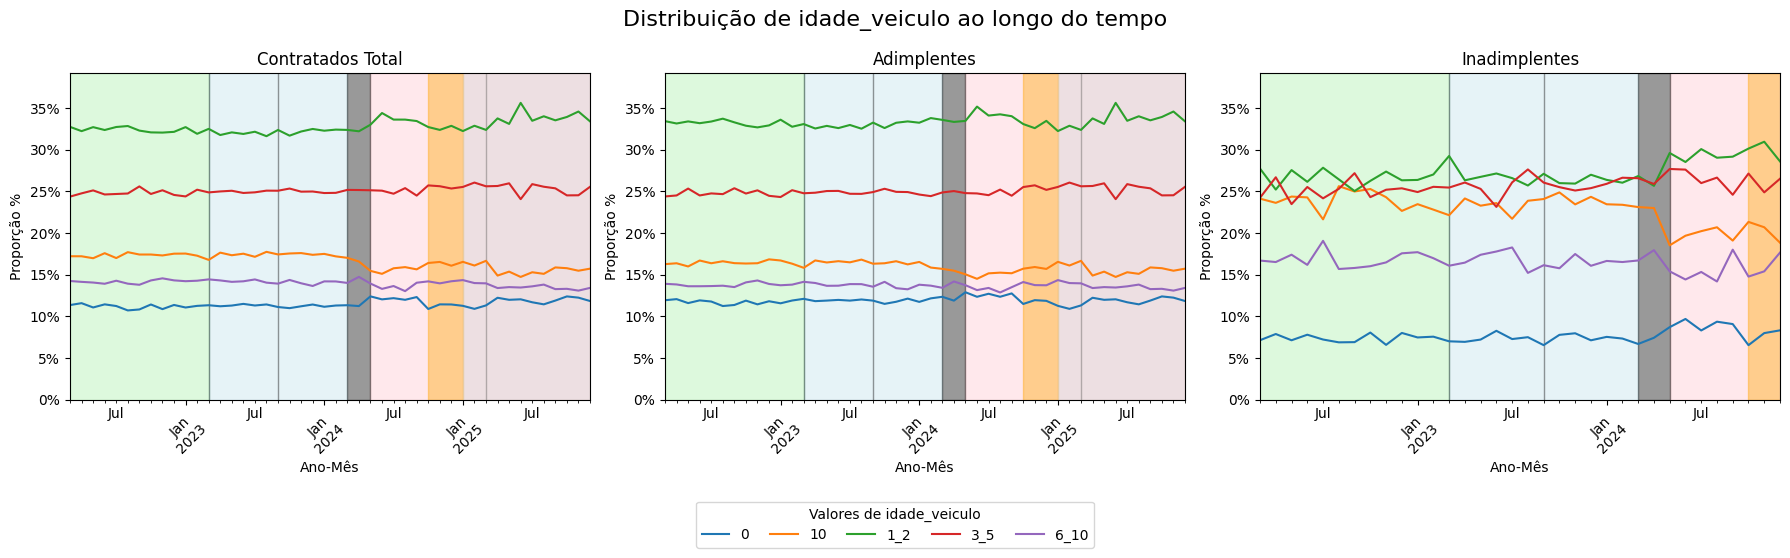

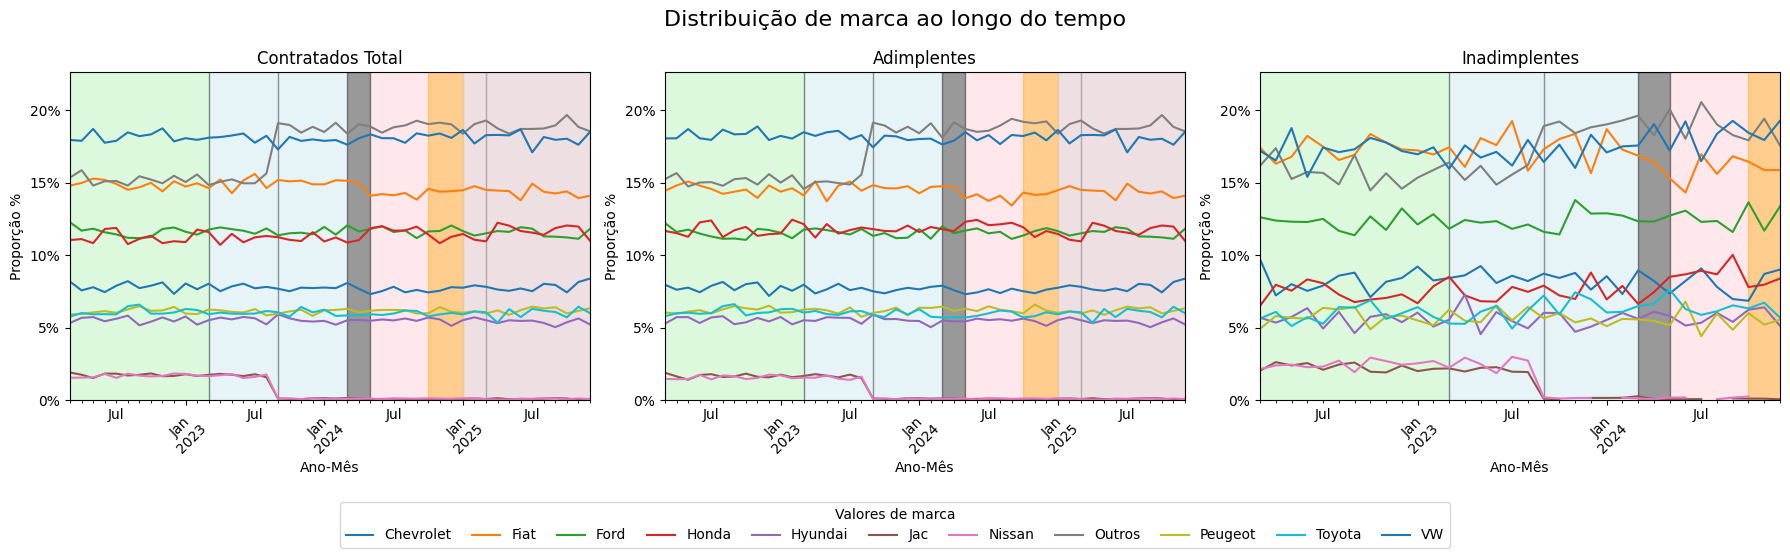

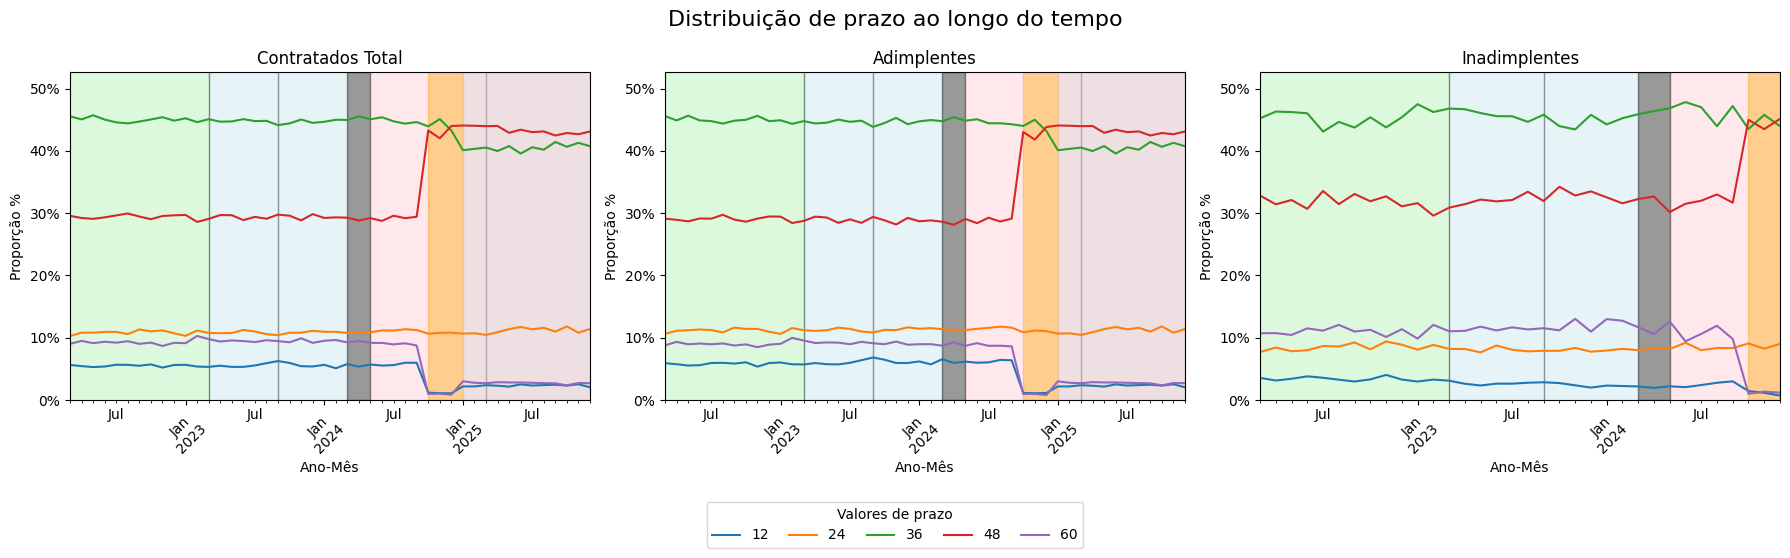

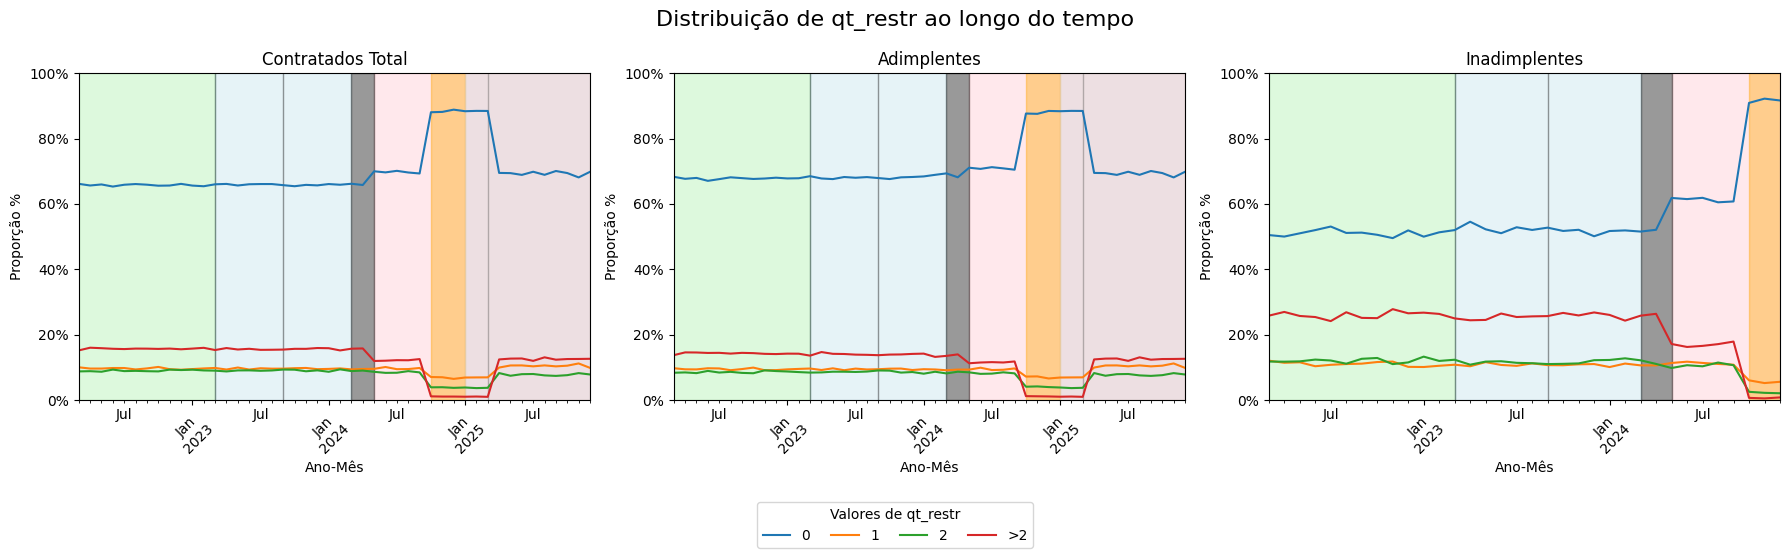

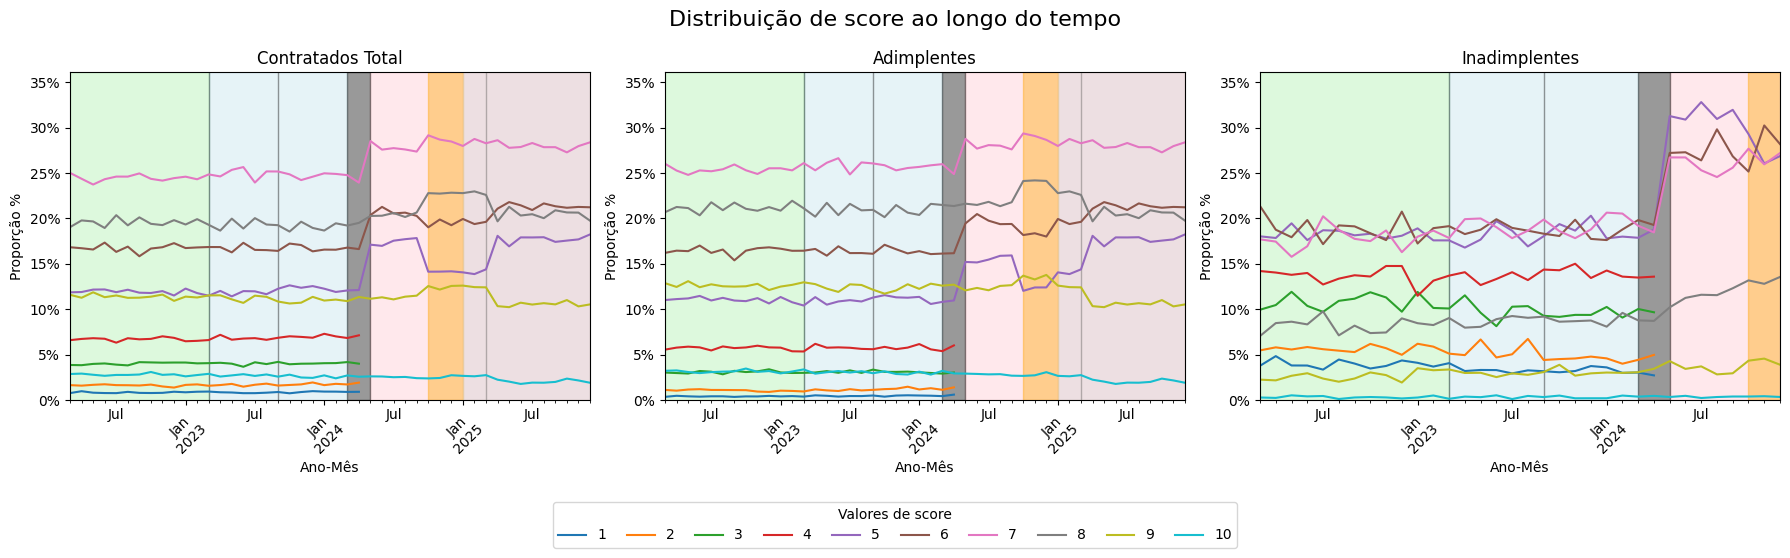

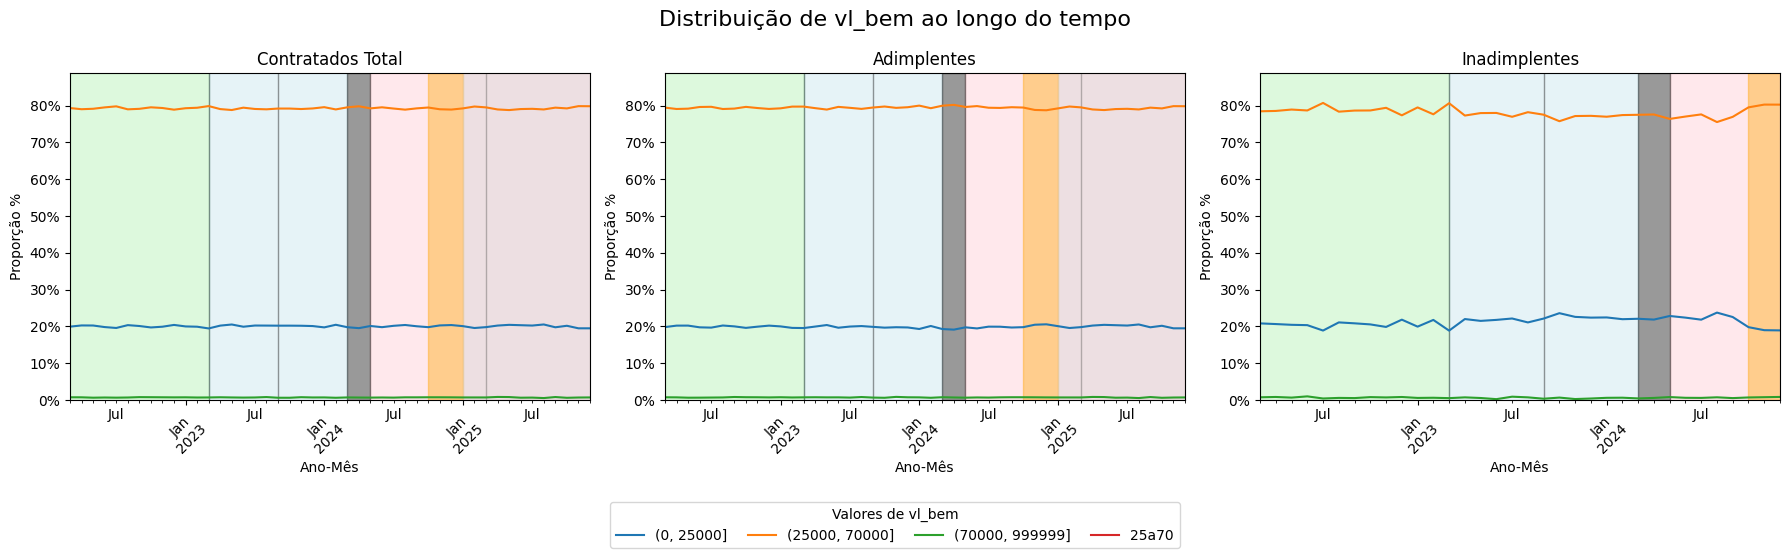

In [100]:
cols = cat_cols

for coluna in cols:
    if coluna in ['ano_mes', 'FPD', 'tipo']:
        continue
    plot_distribuicao_por_grupos(df_contratado, df_adimplente, df_inadimplente, col=coluna)

### 1.2.2. Variáveis Numéricas

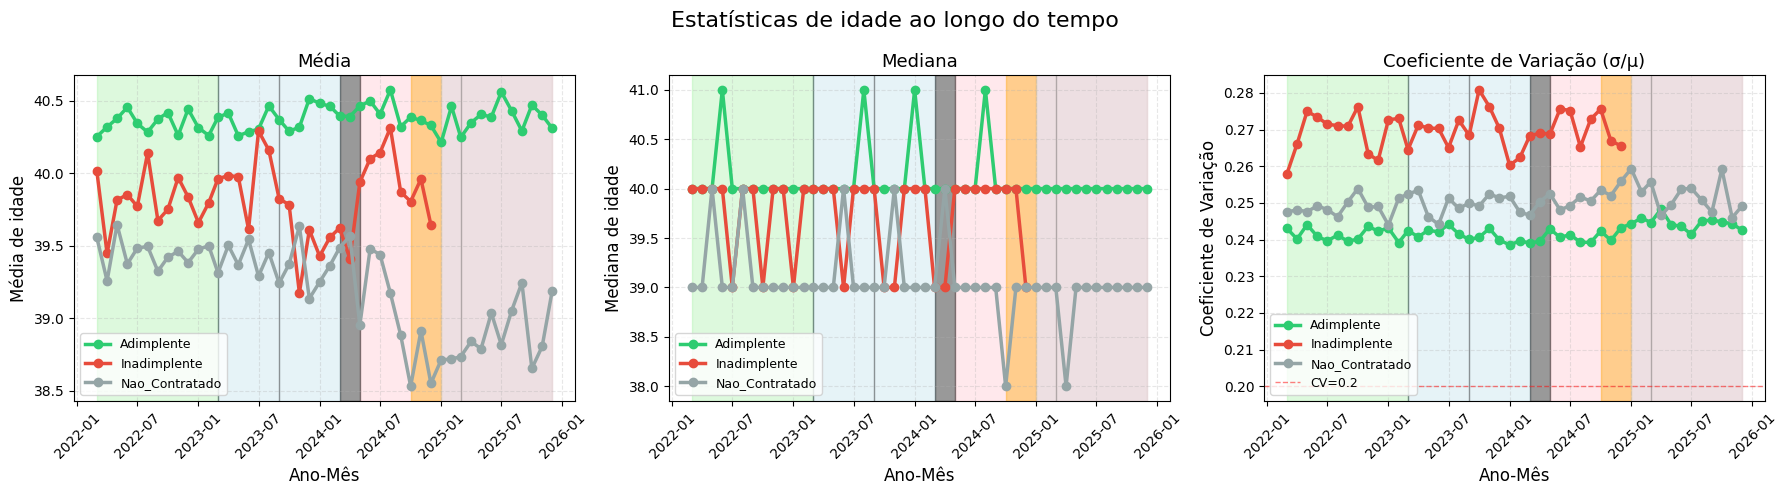

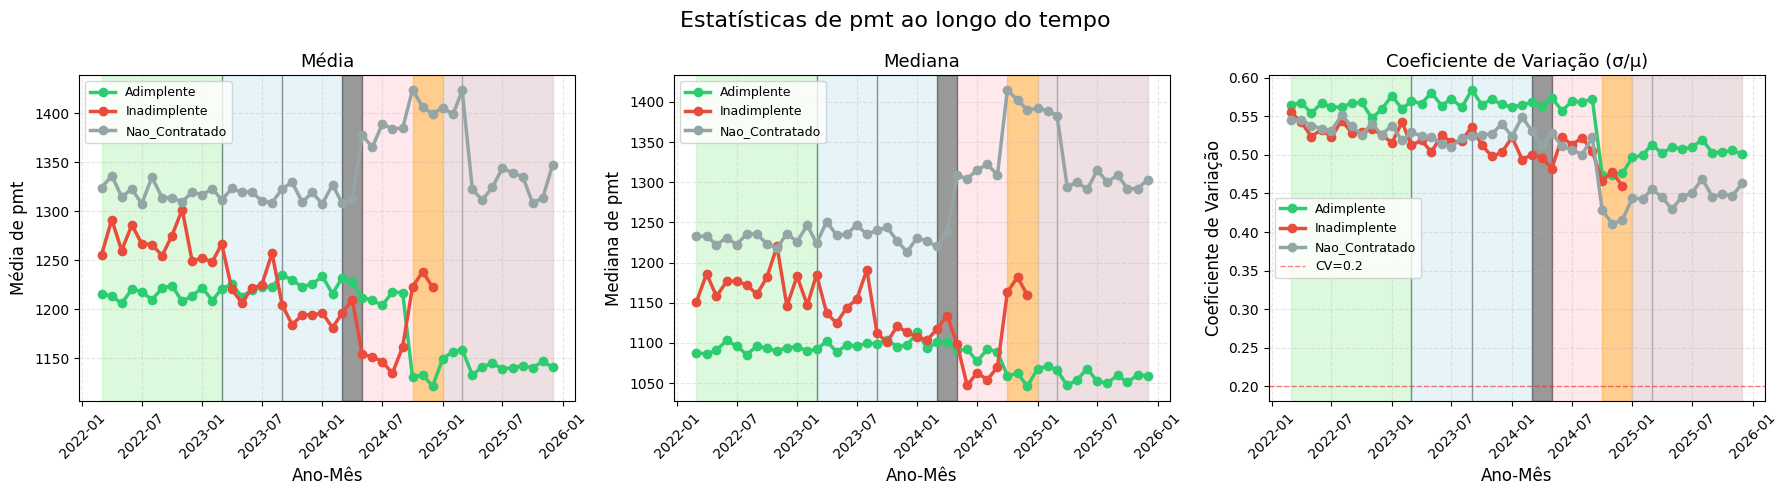

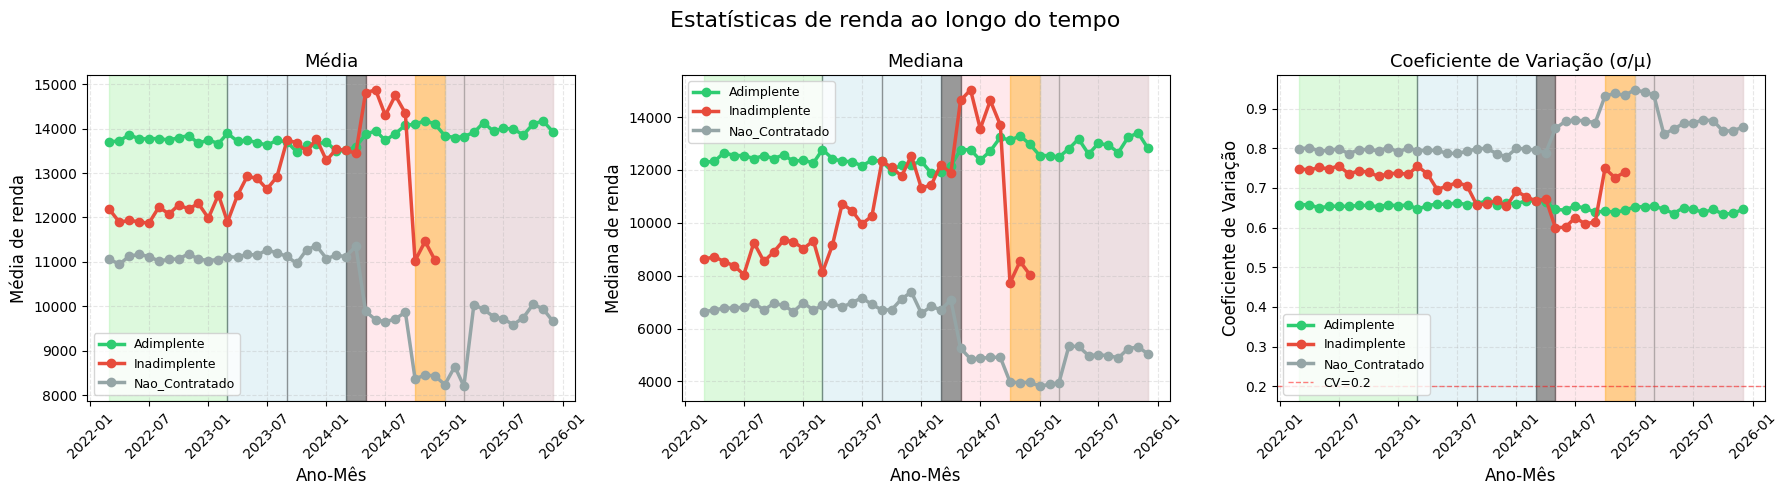

In [101]:
cols = num_cols

for coluna in cols:
    plot_estatisticas_por_tipo(df, coluna)

# 2. Métricas de Monitoramento

## 2.1. Estabilidade

In [ ]:
# Selecionar as informações para análise
# filtro = df[df['ano_mes'] == '2024-03-01']
df_analise_estabilidade = df_inadimplente.copy()

# Selecionar as datas para análise de PSI 
dt_esperada_inicio = '2022-03-01' # Início da Janela de Modelagem
dt_esperada_fim    = '2023-02-01' # Fim da Janela de Modelagem
dt_observacao      = '2024-12-01' # Data da análise

In [126]:
col = 'score'

# Tabela dinâmica de frequência relativa por ano_mes e score
tabela_frequencia = pd.crosstab(df_analise_estabilidade['ano_mes'], df_analise_estabilidade[col], normalize='index')
tabela_frequencia.head(2)

score,1,2,3,4,5,6,7,8,9,10
ano_mes,,,,,,,,,,
2022-03-01,0.037684,0.054615,0.099399,0.141999,0.180229,0.213545,0.176952,0.070453,0.022392,0.002731
2022-04-01,0.048295,0.057955,0.104545,0.140341,0.178409,0.187500,0.174432,0.084659,0.021591,0.002273


### 2.1.1. PSI ou IEP (Índice de Estabilidade do Populacional)

In [ ]:
# Esperado = a média dos valores do período entre 2022-03 e 2023-03 (Janela de Modelagem) para cada score.
esperado = tabela_frequencia.loc[dt_esperada_inicio:dt_esperada_fim].mean()

# Observado = os valores de uma data específica (ex: 2024-03) para cada score.
observado = tabela_frequencia.loc[[dt_observacao]].iloc[0]
observado

# Criar DataFrame com diferença
df_psi = pd.DataFrame({
    'Esperado': esperado,
    'Observado': observado,
    'PSI': (observado - esperado) * np.log(observado / esperado) # PSI = (%Obs - %Esp) * ln(%Obs / %Esp)
})

PSI = df_psi['PSI'].sum()
print(f"PSI Total: {PSI:.4f}")


PSI Total: inf


c:\Users\pwehd\anaconda3\envs\dsa_mm\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [128]:
df_psi.T

score,1,2,3,4,5,6,7,8,9,10
Esperado,0.039447,0.056555,0.107798,0.136282,0.182535,0.188525,0.178036,0.081678,0.026006,0.003138
Observado,0.000000,0.000000,0.000000,0.000000,0.309485,0.298103,0.245528,0.115447,0.028184,0.003252
PSI,inf,inf,inf,inf,0.067025,0.050209,0.021694,0.011685,0.000175,0.000004


### 2.1.2. Carta de Controle

#### 2.1.2.1. Controle do observado (dentro dos limites esperados por score)

In [129]:
# Carta de controle do observado
esperado_std = tabela_frequencia.loc[dt_esperada_inicio:dt_esperada_fim].std()

# Criar DataFrame com diferença
df_controle = pd.DataFrame({
    'Esperado': esperado,
    'Observado': observado,        
    'LS': (esperado + 2 * esperado_std), # Limite Superior = Esperado + 2 * Desvio Padrão
    'LI': (esperado - 2 * esperado_std)  # Limite Inferior = Esperado - 2 * Desvio Padrão
})

df_controle.T

score,1,2,3,4,5,6,7,8,9,10
Esperado,0.039447,0.056555,0.107798,0.136282,0.182535,0.188525,0.178036,0.081678,0.026006,0.003138
Observado,0.000000,0.000000,0.000000,0.000000,0.309485,0.298103,0.245528,0.115447,0.028184,0.003252
LS,0.047996,0.063612,0.124649,0.154364,0.193927,0.214914,0.201956,0.097812,0.036172,0.005626
LI,0.030897,0.049497,0.090947,0.118200,0.171144,0.162137,0.154116,0.065544,0.015839,0.000651


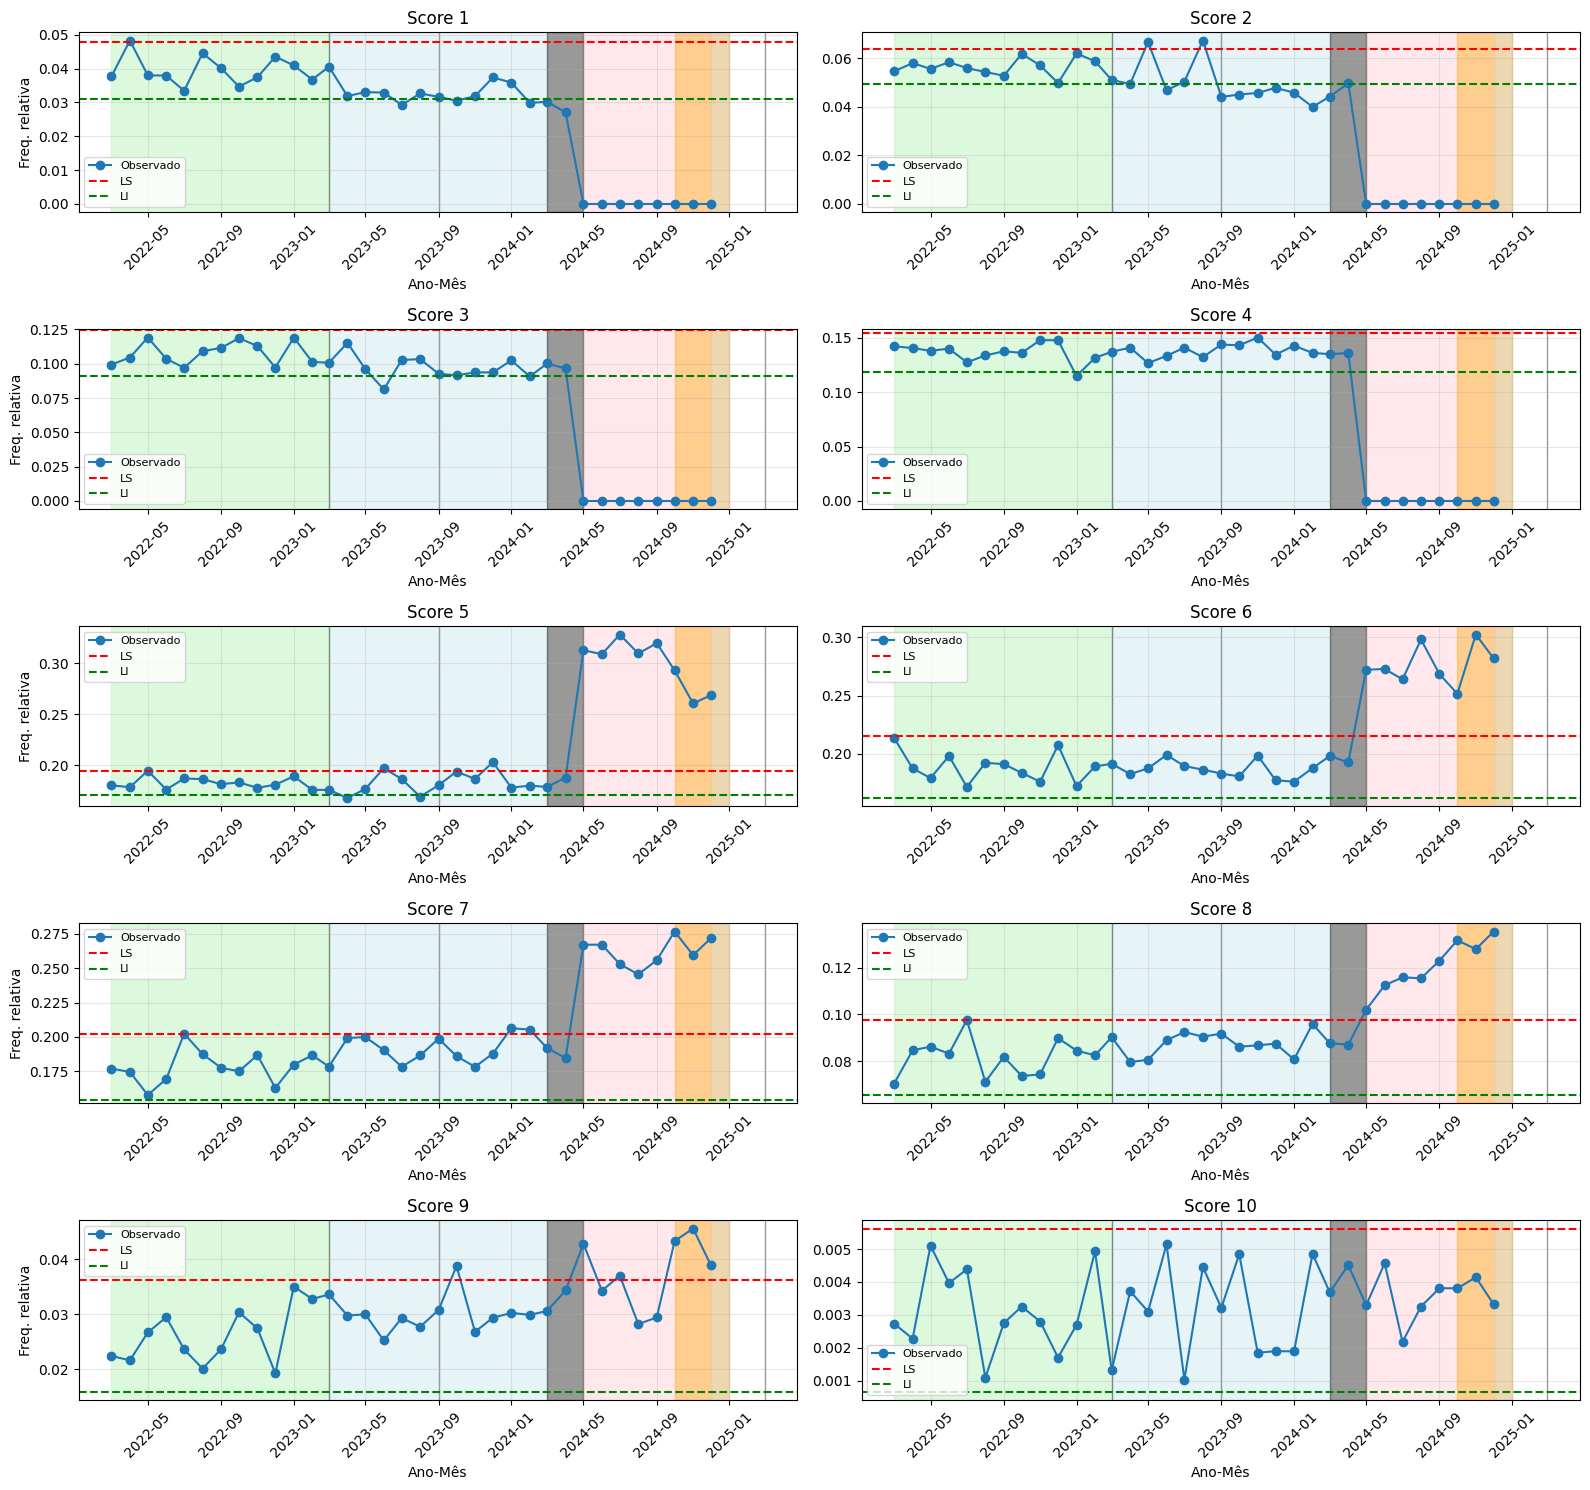

In [ ]:
# Plot da frequência observada por score ao longo do tempo, comparando com LS/LI de cada score
scores = df_controle.index.to_list()
n_scores = len(scores)
n_colunas = 2
n_linhas = (n_scores + n_colunas - 1) // n_colunas  # Arredondar para cima

fig, axes = plt.subplots(n_linhas, n_colunas, figsize=(16, 3 * n_linhas))
axes = axes.flatten()

for i, score in enumerate(scores):
    ax = axes[i]
    serie = tabela_frequencia[score]
    
    ax.plot(serie.index, serie.values, label='Observado', marker='o', linewidth=1.5)
    ax.axhline(df_controle.loc[score, 'LS'], color='red', linestyle='--', label='LS')
    ax.axhline(df_controle.loc[score, 'LI'], color='green', linestyle='--', label='LI')
    
    ax.axvspan('2022-03-01', '2023-03-01', color='lightgreen', alpha=0.3)                    # Janela de Modelagem
    ax.axvspan('2023-03-01', '2024-03-01', color='lightblue', alpha=0.3)                     # Janela de Observação
    ax.axvspan('2024-05-01', tabela_frequencia.index.max(), color='lightpink', alpha=0.3)    # Em Produção
    ax.axvspan('2024-03-01', '2024-05-01', color='black', alpha=0.4)                         # Limbo
    ax.axvspan('2023-03-01', '2023-03-01', color='black', alpha=0.4)                         # Marcador
    ax.axvspan('2023-09-01', '2023-09-01', color='black', alpha=0.4)                         # Efeito Modelo Teste
    ax.axvspan('2025-03-01', '2025-03-01', color='black', alpha=0.4)                         # Marcador
    ax.axvspan('2024-10-01', '2025-01-01', color='orange', alpha=0.4)                        # Efeito Modelo Produção
    ax.axvspan('2025-01-01', tabela_frequencia.index.max(), color='lightgray', alpha=0.4)    # Não tem target 1
    
    ax.set_title(f'Score {score}')
    ax.set_xlabel('Ano-Mês')
    if i % n_colunas == 0:
        ax.set_ylabel('Freq. relativa')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

# Esconder subplots vazios (se houver)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

#### 2.1.2.2. Controle da variação média ponderada por score

In [131]:
# Carta de Controle

# Média ponderada do score por mês (soma produto = frequência * score)
scores = tabela_frequencia.columns.to_list()
media_ponderada_score_por_mes = tabela_frequencia.dot(scores)

# Desvio padrão do período da janela de modelagem (2022-03 a 2023-02)
std_ponderado_esperado = media_ponderada_score_por_mes.loc[dt_esperada_inicio:dt_esperada_fim].std() 
mean_ponderado_esperado = media_ponderada_score_por_mes.loc[dt_esperada_inicio:dt_esperada_fim].mean()

# Adicionar limites de controle
limite_superior = mean_ponderado_esperado + 2 * std_ponderado_esperado # Limite Superior
limite_inferior = mean_ponderado_esperado - 2 * std_ponderado_esperado # Limite Inferior

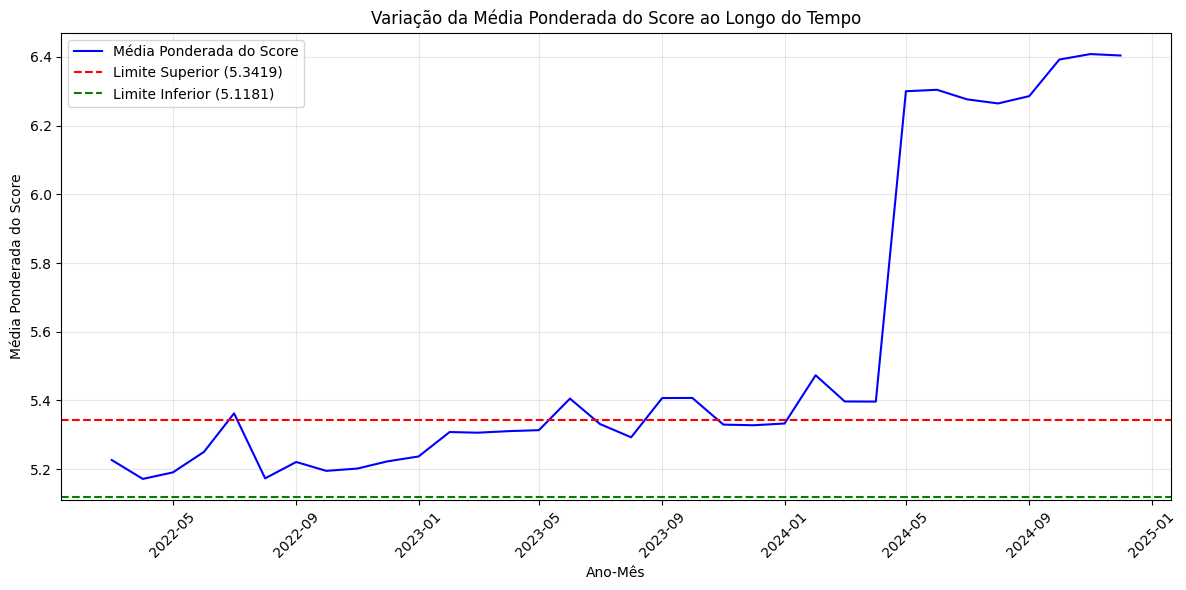

In [132]:
# Plotar a variação da média ponderada do score ao longo do tempo
plt.figure(figsize=(12, 6))
plt.plot(media_ponderada_score_por_mes.index, media_ponderada_score_por_mes.values, label='Média Ponderada do Score', color='blue')

# Adicionar linhas para os limites superior e inferior
plt.axhline(y=limite_superior, color='red', linestyle='--', label=f'Limite Superior ({limite_superior:.4f})')
plt.axhline(y=limite_inferior, color='green', linestyle='--', label=f'Limite Inferior ({limite_inferior:.4f})')

# Configurações do gráfico
plt.title('Variação da Média Ponderada do Score ao Longo do Tempo')
plt.xlabel('Ano-Mês')
plt.ylabel('Média Ponderada do Score')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2.2. Discriminação (O mais relevante)

### 

## 2.3. Previsibilidade